In [ ]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_scheduler
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler

# **1. LOAD DATASET & CLEANING**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SEMESTER 5/Klasifikasi Teks Artikel Berita/news-article-3.csv')

In [ ]:
# Menghapus data kosong
df.dropna(subset=['body'], inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
# Preprocessing teks: menghapus angka, simbol, dan mengubah ke lowercase
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Hanya huruf dan spasi
    return text.lower()

df['body'] = df['body'].apply(clean_text)

In [ ]:
# Print jumlah data setelah preprocessing
print(f"Total data setelah cleaning: {len(df)}")


Total data setelah cleaning: 6844


In [ ]:
# Encode kategori
le = LabelEncoder()
df['category'] = le.fit_transform(df['category'])
print("Kategori yang tersedia:", le.classes_)


Kategori yang tersedia: ['ARTS & CULTURE' 'BUSINESS' 'COMEDY' 'CRIME' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'MEDIA' 'POLITICS' 'RELIGION' 'SCIENCE' 'SPORTS' 'TECH'
 'WOMEN']


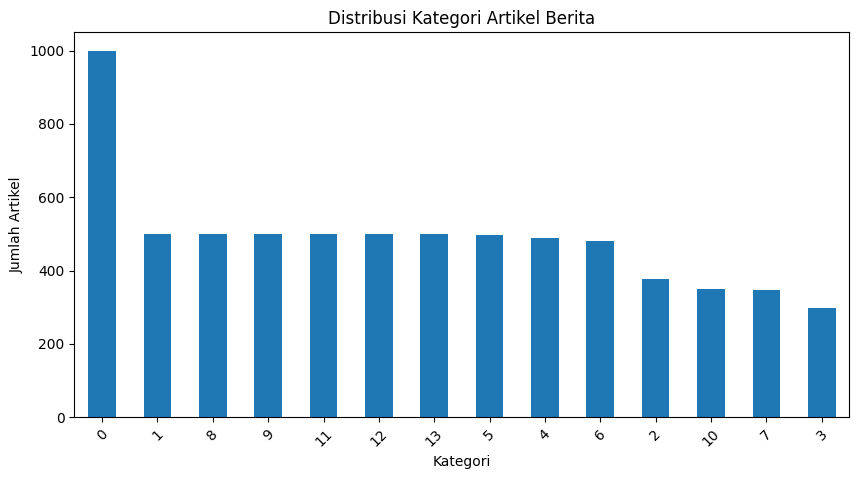

In [ ]:
# import matplotlib.pyplot as plt

# Menampilkan distribusi kategori dalam bentuk diagram batang
plt.figure(figsize=(10,5))
df['category'].value_counts().plot(kind='bar')
plt.title("Distribusi Kategori Artikel Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Artikel")
plt.xticks(rotation=45)
plt.show()


# **2. DATA SPLIT**

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['body'], df['category'], test_size=0.2, random_state=42, stratify=df['category']
)
print(f"Jumlah data training: {len(train_texts)}, Jumlah data validasi: {len(val_texts)}")

Jumlah data training: 5475, Jumlah data validasi: 1369


# **3. TOKENIZATION**

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 256  # Meningkatkan jumlah token yang diproses
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=max_length)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=max_length)

# Konversi ke tensor
train_dataset = TensorDataset(
    torch.tensor(train_encodings['input_ids']),
    torch.tensor(train_encodings['attention_mask']),
    torch.tensor(train_labels.to_numpy())
)
val_dataset = TensorDataset(
    torch.tensor(val_encodings['input_ids']),
    torch.tensor(val_encodings['attention_mask']),
    torch.tensor(val_labels.to_numpy())
)

# Buat DataLoader
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

# **4. MODEL SETUP**

In [ ]:
num_labels = len(df['category'].unique())
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels).to('cuda')

# Optimizer dan Scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_training_steps = 5 * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

# **5. TRAINING**

In [ ]:
# TRAINING DENGAN VALIDATION LOSS PLOT

epochs = 10
gradient_accumulation_steps = 2
scaler = torch.amp.GradScaler()
train_losses = []
val_losses = []

model.train()
for epoch in range(epochs):
    total_train_loss = 0
    total_val_loss = 0

    # Training Loop
    for batch in train_loader:
        input_ids, attention_masks, labels = [b.to('cuda') for b in batch]
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(input_ids, attention_mask=attention_masks, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        total_train_loss += loss.item()

    # Validation Loop
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_masks, labels = [b.to('cuda') for b in batch]
            outputs = model(input_ids, attention_mask=attention_masks, labels=labels)
            val_loss = outputs.loss.item()
            total_val_loss += val_loss

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')


# **6. EVALUASI MODEL**

In [ ]:
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_masks, labels = [b.to('cuda') for b in batch]
        outputs = model(input_ids, attention_mask=attention_masks)
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)
print(f'Validation Accuracy: {accuracy:.4f}')
print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=le.classes_))

# **7. VISUALISASI HASIL**

In [ ]:
# Heatmap Confusion Matrix
plt.figure(figsize=(10,7))
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Membuat plot Training Loss vs Validation Loss
plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='o')

# Label dan judul grafik
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)

# Menampilkan grafik
plt.show()


In [ ]:
# F1-score per kategori
report = classification_report(true_labels, predictions, target_names=le.classes_, output_dict=True)
f1_scores = {category: report[category]['f1-score'] for category in le.classes_}
plt.figure(figsize=(12,5))
plt.barh(list(f1_scores.keys()), list(f1_scores.values()), color='skyblue')
plt.xlabel("F1-score")
plt.title("F1-score per Category")
plt.show()

# **8. PREDIKSI TEKS BARU**

In [ ]:
def predict_text(text, model, tokenizer, label_encoder):
    model.eval()
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=256)
    encoded_input = {key: value.to('cuda') for key, value in encoded_input.items()}

    with torch.no_grad():
        output = model(**encoded_input)
        predicted_class = torch.argmax(output.logits, dim=1).item()

    predicted_category = label_encoder.inverse_transform([predicted_class])
    return predicted_category[0]

# Input teks dari pengguna
user_input = input("Masukkan teks artikel untuk diprediksi: ")
predicted_category = predict_text(user_input, model, tokenizer, le)
print(f'Predicted Category: {predicted_category}')

In [ ]:
def predict_text(text, model, tokenizer, label_encoder):
    model.eval()
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=256)
    encoded_input = {key: value.to('cuda') for key, value in encoded_input.items()}

    with torch.no_grad():
        output = model(**encoded_input)
        predicted_class = torch.argmax(output.logits, dim=1).item()

    predicted_category = label_encoder.inverse_transform([predicted_class])
    return predicted_category[0]

# Input teks dari pengguna
user_input = input("Masukkan teks artikel untuk diprediksi: ")
predicted_category = predict_text(user_input, model, tokenizer, le)
print(f'Predicted Category: {predicted_category}')

In [ ]:
def predict_text(text, model, tokenizer, label_encoder):
    model.eval()
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=256)
    encoded_input = {key: value.to('cuda') for key, value in encoded_input.items()}

    with torch.no_grad():
        output = model(**encoded_input)
        predicted_class = torch.argmax(output.logits, dim=1).item()

    predicted_category = label_encoder.inverse_transform([predicted_class])
    return predicted_category[0]

# Input teks dari pengguna
user_input = input("Masukkan teks artikel untuk diprediksi: ")
predicted_category = predict_text(user_input, model, tokenizer, le)
print(f'Predicted Category: {predicted_category}')